# Support Vector Machine

In [ ]:
'''
- Does both classification and Regression.
Classification -> Support vector classifier
Regression -> Support Vector Regressor

- It requires small amount of data.

- Linear Separable Data
- Non-Linear Separable Data

1. Hyperplane
2. Margins
3. Support Vectors
4. Model Arguments
    a. kernel = 'linear', 'rbf (radial basis function) (default)', 'poly'
    b. C -> 0.01, 0.1, 1, 10, 100 -> gap between margin and hyperplane
    c. gamma -> scale, 0.01, 0.1, 1, 10, 100 -> Create curve line for kernel rbf or poly
'''

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Import SVM Model
from sklearn.svm import SVC
# import train test split
from sklearn.model_selection import train_test_split
# import scaler
from sklearn.preprocessing import StandardScaler
# import metrics
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
df = pd.read_csv('Dataset/cardiovascular_disease.csv')
df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [3]:
df['age'] = df['age']//365

In [4]:
df = df[
    (df['height'].between(145, 185)) & 
    (df['weight'].between(45, 120)) &
    (df['ap_hi'].between(90, 200)) &
    (df['ap_lo'].between(50, 90))
]

In [15]:
## extract sample
sample_data = df.sample(n=10000, random_state=42)
# sample_data.columns

#### Features and Target

In [16]:
features = ['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 
            'alco', 'active']
target = 'cardio'

X = sample_data[features]
Y = sample_data[target]

#### Train and Test

In [17]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42, stratify=Y
)

#### Feature Scaling

In [18]:
scaler = StandardScaler()
X_train_scale = scaler.fit_transform(X_train)
X_test_scale = scaler.transform(X_test)

#### Model Implementation

In [19]:
model = SVC(
    kernel='rbf', C=0.01, gamma='scale'
)
model.fit(X_train_scale, Y_train)

,C,0.01
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [20]:
Y_pred = model.predict(X_test_scale)

# Metrics

In [21]:
cr = classification_report(Y_test, Y_pred)
cm = confusion_matrix(Y_test, Y_pred)

In [22]:
print(cr)

              precision    recall  f1-score   support

           0       0.71      0.82      0.76      1064
           1       0.75      0.63      0.69       936

    accuracy                           0.73      2000
   macro avg       0.73      0.72      0.72      2000
weighted avg       0.73      0.73      0.73      2000



In [23]:
print(cm)

[[870 194]
 [347 589]]


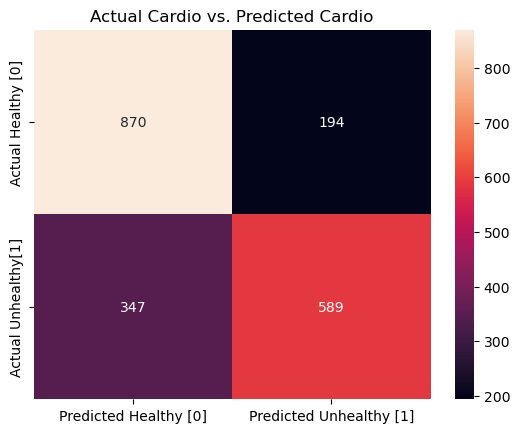

In [26]:
sns.heatmap(cm, annot=True, fmt='1.0f', xticklabels=['Predicted Healthy [0]', 'Predicted Unhealthy [1]'],
           yticklabels=['Actual Healthy [0]', 'Actual Unhealthy[1]'])
plt.title('Actual Cardio vs. Predicted Cardio')
plt.show()

#### New data prediction

In [44]:
data = {
    'age': [35, 29, 40, 60], 
    'gender': [1, 2, 1, 2], 
    'height': [150, 147, 160, 170], 
    'weight': [55, 60, 45, 80], 
    'ap_hi': [130, 120, 140, 120], 
    'ap_lo': [80, 80, 50, 90], 
    'cholesterol': [1, 1, 3, 2], 
    'gluc': [1, 1, 1, 2], 
    'smoke': [0, 0, 0, 1], 
    'alco': [1, 1, 0, 0], 
    'active': [0, 1, 1, 0]
}

In [45]:
X_data = pd.DataFrame(data)
# X_data

In [46]:
X_scale = scaler.transform(X_data)
# X_scale

In [47]:
Y_new_pred = model.predict(X_scale)

In [48]:
X_data['Cardio'] = Y_new_pred
X_data

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,Cardio
0,35,1,150,55,130,80,1,1,0,1,0,1
1,29,2,147,60,120,80,1,1,0,1,1,1
2,40,1,160,45,140,50,3,1,0,0,1,1
3,60,2,170,80,120,90,2,2,1,0,0,1
